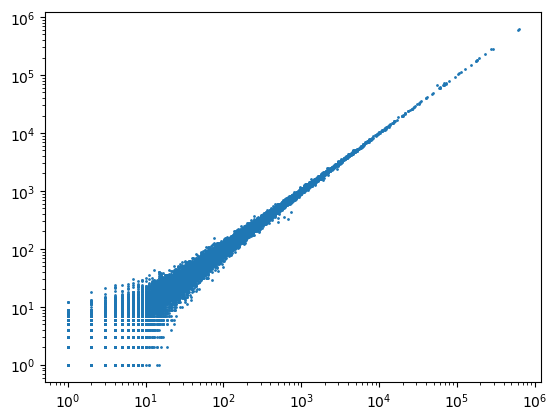

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

counts_df = pd.read_table(
    '../../results/mouse_muscle/star_align/A1/ReadsPerGene.out.tab',
    header=None, index_col=0, skiprows=4,
)

first_stranded = counts_df.iloc[:, 1]
second_stranded = counts_df.iloc[:, 2]

plt.scatter(first_stranded, second_stranded, s=1)
plt.xscale('log')
plt.yscale('log')

plt.show()


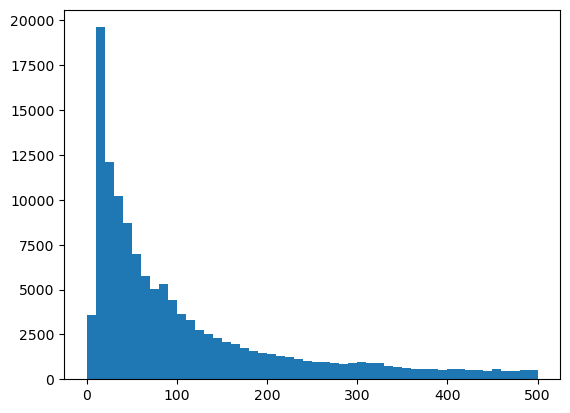

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

sj_df = pd.read_table('../../results/hela_tm_tg/junctions/non_canonical_junctions.all.tsv')

sj_length = sj_df['end'] - sj_df['start']

plt.hist(sj_length.to_numpy(), bins=50, range=(0, 500))
plt.show()

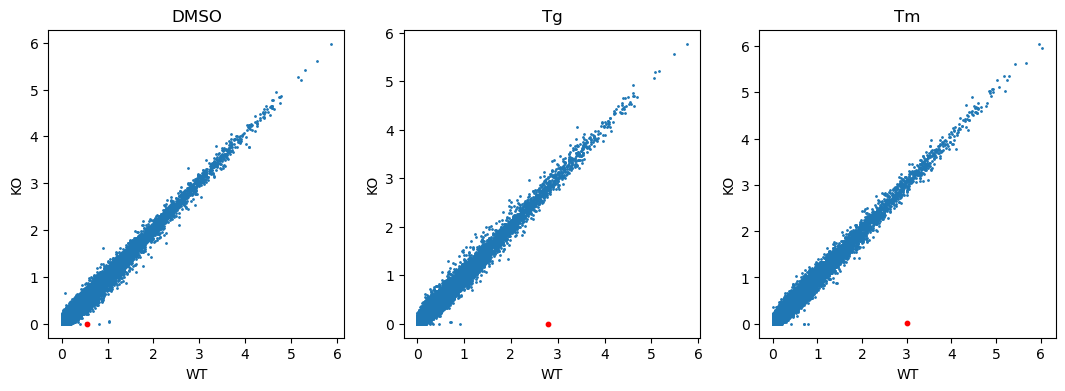

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sj_cpm_df = pd.read_table('../../results/hela_tm_tg/junctions/SJ_nc_2pass_nc.cpm.tsv')

plt.figure(figsize=(13, 4))
for i, treatment in enumerate(['DMSO', 'Tg', 'Tm']):
    sj_cpm_df['WT'] = np.log(sj_cpm_df[f'WT_{treatment}_1'] + sj_cpm_df[f'WT_{treatment}_2'] + 1)
    sj_cpm_df['KO'] = np.log(sj_cpm_df[f'KO_{treatment}_1'] + sj_cpm_df[f'KO_{treatment}_2'] + 1)

    #high_df = sj_cpm_df[(sj_cpm_df['WT'] > 0.5) & (sj_cpm_df['KO'] < 0.1)]
    #print(high_df)

    xbp1_point = sj_cpm_df.query("chr == 'chr22' and start == 28796128 and end == 28796153")
    
    plt.subplot(1, 3, i + 1)
    plt.scatter(data=sj_cpm_df, x='WT', y='KO', s=1)
    plt.scatter(data=xbp1_point, x='WT', y='KO', color='red', s=10)
    plt.title(treatment)
    plt.xlabel('WT')
    plt.ylabel('KO')

plt.show()


In [1]:
import pandas as pd
import numpy as np

sj_count_df = pd.read_table(
    '../../results/hela_tm_tg/junctions/SJ_nc_2pass_nc.count.tsv'
)
# 1-based to 0-based
sj_count_df['start'] = sj_count_df['start'] - 1

sj_genes = pd.read_table(
    '../../results/hela_tm_tg/junctions/SJ_nc_2pass_nc.genes.bed',
    header=None, names=['chr', 'start', 'end', 'genes'], index_col=[0, 1, 2]
)

sj_count_df = sj_count_df.join(sj_genes, on=['chr', 'start', 'end'])
sj_count_df.dropna(subset=['genes'], inplace=True)
sj_count_df.set_index(['chr', 'start', 'end'], inplace=True)

sj_count_df['genes'] = sj_count_df['genes'].str.split(';')

gene_counts = pd.read_table(
    '../../results/hela_tm_tg/feature_counts_2pass_nc.all.matrix.tsv', index_col=0
)
data_columns = gene_counts.columns

def get_counts(row):
    genes = row['genes']
    gene_counts_sum = gene_counts.loc[genes].sum()
    return gene_counts_sum

gene_counts_df = sj_count_df.apply(get_counts, axis=1)
sj_count_df[data_columns] = sj_count_df[data_columns] / gene_counts_df
sj_count_df.fillna(0, inplace=True)
sj_count_df


strand  annotated  KO_DMSO_1  KO_DMSO_2   KO_Tg_1  \
chr  start end                                                         
chr1 14711 19191        0          1   0.020942   0.013746  0.009804   
     14826 14959        0          1   0.010471   0.000000  0.000000   
     15817 186338       0          1   0.303846   0.260341  0.268852   
     15820 186341       0          1   0.096154   0.075426  0.088525   
     15873 186371       0          1   0.000000   0.004866  0.006557   
...                   ...        ...        ...        ...       ...   
chrM 8754  11988        0          0   0.000000   0.000000  0.000000   
     9300  9321         0          0   0.000000   0.000000  0.000000   
     9357  15528        0          0   0.000000   0.000000  0.000000   
     10519 10570        0          0   0.000000   0.000000  0.000000   
     10713 10918        0          0   0.000000   0.000000  0.000000   

                    KO_Tg_2   KO_Tm_1   KO_Tm_2  WT_DMSO_1  WT_DMSO_2  \
chr  start end                                                          
chr1 14711 19191   0.008850  0.016807  0.006536   0.013793   0.019608   
     14826 14959   0.000000  0.004202  0.003268   0.000000   0.000000   
     15817 186338  0.265823  0.266667  0.187654   0.271795   0.177852   
     15820 186341  0.088608  0.096970  0.054321   0.069231   0.050336   
     15873 186371  0.006329  0.015152  0.012346   0.010256   0.003356   
...                     ...       ...       ...        ...        ...   
chrM 8754  11988   0.000000  0.000000  0.000000   0.000000   0.000000   
     9300  9321    0.000000  0.000000  0.000000   0.000000   0.000000   
     9357  15528   0.000000  0.000000  0.000000   0.000000   0.000000   
     10519 10570   0.000000  0.000000  0.000000   0.000000   0.000000   
     10713 10918   0.000000  0.000000  0.000000   0.000000   0.000000   

                    WT_Tg_1   WT_Tg_2   WT_Tm_1       WT_Tm_2  \
chr  start end                                                  
chr1 14711 19191   0.014599  0.010490  0.017964  0.000000e+00   
     14826 14959   0.003650  0.000000  0.000000  0.000000e+00   
     15817 186338  0.261084  0.343590  0.228070  3.103448e-01   
     15820 186341  0.066502  0.110256  0.065789  7.183908e-02   
     15873 186371  0.004926  0.000000  0.000000  8.620690e-03   
...                     ...       ...       ...           ...   
chrM 8754  11988   0.000000  0.000000  0.000000  1.197262e-06   
     9300  9321    0.000000  0.000000  0.000000  4.584674e-06   
     9357  15528   0.000000  0.000000  0.000000  9.236391e-07   
     10519 10570   0.000000  0.000000  0.000000  1.674817e-05   
     10713 10918   0.000000  0.000000  0.000000  2.134686e-06   

                                                               genes  
chr  start end                                                        
chr1 14711 19191   [ENSG00000227232.6, ENSG00000278267.1, ENSG000...  
     14826 14959   [ENSG00000227232.6, ENSG00000290825.2, ENSG000...  
     15817 186338  [ENSG00000186092.7, ENSG00000222623.1, ENSG000...  
     15820 186341  [ENSG00000186092.7, ENSG00000222623.1, ENSG000...  
     15873 186371  [ENSG00000186092.7, ENSG00000222623.1, ENSG000...  
...                                                              ...  
chrM 8754  11988   [ENSG00000198840.2, ENSG00000198886.2, ENSG000...  
     9300  9321                                  [ENSG00000198938.2]  
     9357  15528   [ENSG00000198695.2, ENSG00000198727.2, ENSG000...  
     10519 10570                                 [ENSG00000212907.2]  
     10713 10918              [ENSG00000198886.2, ENSG00000212907.2]  

[267610 rows x 15 columns]

                                   WT           KO
chr   start     end                               
chr6  131328163 131343586  796.000000  1396.333333
      131300100 131328045  460.000000   518.666667
chr11 62571616  62571666   214.666667   120.000000
      65499810  65499911   161.476190   225.500000
      62571675  62571854   133.333333    84.000000
      62571102  62572642   131.333333    99.666667
      62571055  62571094   116.000000    64.833333
      62571021  62571074   100.333333    81.166667
      65500571  65500619    99.404762   137.500000
      65499714  65499840    81.071429   144.750000
                               WT   KO
chr   start    end                    
chr22 28796127 28796153  0.004205  0.0
                                   WT          KO
chr   start     end                              
chr6  131328163 131343586  216.214286  443.250000
      131300100 131328045  118.071429  229.250000
chr11 65499810  65499911   104.993506  239.500000
chrX  4541978   52084

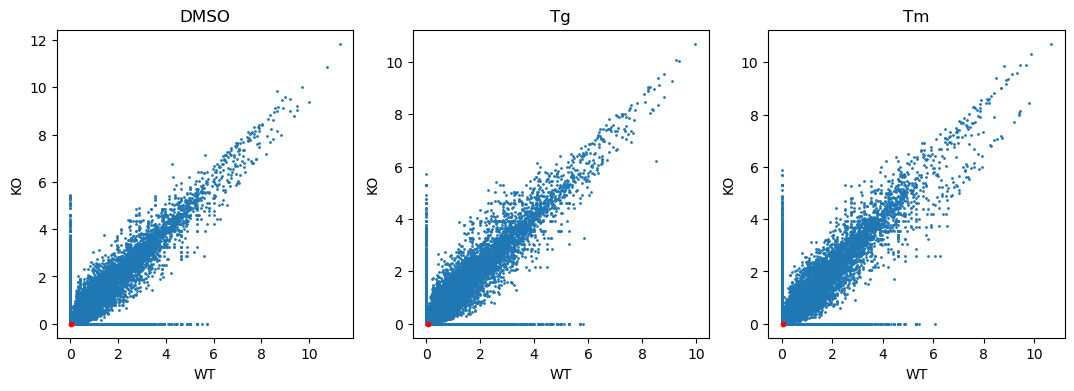

In [ ]:
import matplotlib.pyplot as plt

plot_df = sj_count_df.copy()
plot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
plot_df.dropna(subset=data_columns, inplace=True)

plt.figure(figsize=(13, 4))
for i, treatment in enumerate(['DMSO', 'Tg', 'Tm']):
    plot_df['WT'] = plot_df[f'WT_{treatment}_1'] + plot_df[f'WT_{treatment}_2']
    plot_df['KO'] = plot_df[f'KO_{treatment}_1'] + plot_df[f'KO_{treatment}_2']

    # sort_df = plot_df.sort_values('WT', ascending=False)
    xbp1_point = plot_df.query("chr == 'chr22' and start == 28796127 and end == 28796153")
    print(xbp1_point[['WT', 'KO']])

    plot_df['WT'] = np.log(plot_df['WT'] * 100 + 1)
    plot_df['KO'] = np.log(plot_df['KO'] * 100 + 1)
    
    plt.subplot(1, 3, i + 1)
    plt.scatter(data=plot_df, x='WT', y='KO', s=1)
    plt.scatter(data=xbp1_point, x='WT', y='KO', color='red', s=10)
    plt.title(treatment)
    #plt.xscale('log')
    #plt.yscale('log')
    plt.xlabel('WT')
    plt.ylabel('KO')

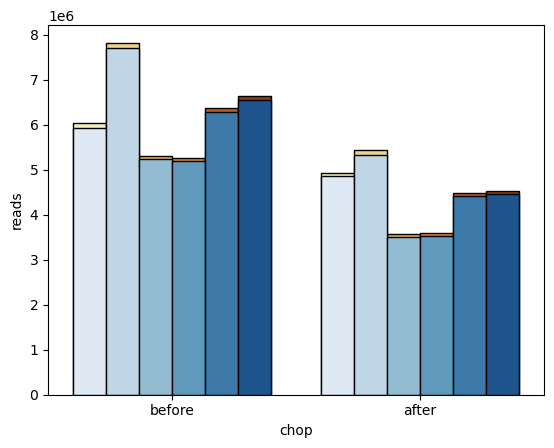

In [15]:
# ["total count", "primary mapped count", "total after porechop", "primary mapped after porechop"]
ont_sam = {
    'WT_DMSO': [6036026, 5928209, 4934811, 4858028],
    'KO_DMSO': [7827190, 7699402, 5432376, 5339740],
    'WT_Tg': [5315314, 5231961, 3573796, 3515744],
    'KO_Tg': [5272757, 5187493, 3585209, 3525469],
    'WT_Tm': [6383810, 6291425, 4490481, 4426858],
    'KO_Tm': [6651356, 6553087, 4534631, 4460029],
}

import seaborn as sns
import pandas as pd

# create stacked bar plot, group by before and after porechop, stack mapped and (total - mapped)

df = pd.DataFrame(ont_sam, dtype=int).T
before_chop = df[[0, 1]].copy()
after_chop = df[[2, 3]].copy()
after_chop.columns = before_chop.columns
before_chop['chop'] = 'before'
after_chop['chop'] = 'after'
stacked_df = pd.concat([before_chop, after_chop])
stacked_df.reset_index(inplace=True, names=['sample'])
stacked_df.columns = ['sample', 'total', 'mapped', 'chop']
stacked_df['unmapped'] = stacked_df['total'] - stacked_df['mapped']
stacked_df.drop(columns=['total'], inplace=True)
stacked_df = pd.melt(stacked_df, id_vars=['sample', 'chop'], value_vars=['mapped', 'unmapped'], var_name='mapping_status', value_name='count')
stacked_df.set_index(['mapping_status', 'sample', 'chop'], inplace=True)
stacked_df['reads'] = stacked_df.groupby(level=['sample', 'chop']).cumsum()
stacked_df.reset_index(inplace=True)

c = ["Blues", "YlOrBr"]
for i, g in enumerate(stacked_df.groupby('mapping_status')):
    ax = sns.barplot(
        data=g[1], x='chop', y='reads', hue='sample',
        palette=c[i], zorder=-i, edgecolor='k'
    )
ax.legend_.remove()


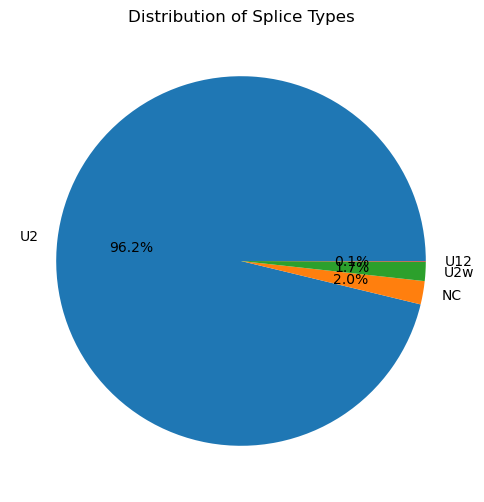

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

stringtie_sites = pd.read_table('../../results/hela_tm_tg_mix/stringtie_viral/merged.splice_sites.with_types.tsv')
types_count = stringtie_sites['splice_type'].value_counts()

# pie plot
plt.figure(figsize=(6, 6))
plt.pie(types_count, labels=types_count.index, autopct='%1.1f%%')
plt.title('Distribution of Splice Types')
plt.show()
